# Procesamiento Digital de Señales y Series Temporales
## Análisis de la acción YPF (2018–2025)

**Materia:** Procesamiento Digital de Señales

**Cuatrimestre:** Primer Cuatrimestre 2026

**Integrantes:** Joaquín Gándara Stepñicka, Agustina Borsato, Mauro Azzollini y Victor Asmad Murga

**Carrera:** Licenciatura en Ciencias de la Computación  

**Dataset:** Cotización histórica de YPF (NYSE: YPF) — obtenido via `yfinance` (yfinance es una librería de Python que permite descargar datos financieros de forma sencilla desde Yahoo Finance.)

---

## 1. Introducción

### ¿Qué es YPF?

YPF S.A. (Yacimientos Petrolíferos Fiscales) es la empresa de energía más grande de Argentina. Fundada en 1922, opera en la exploración, producción, refinación y comercialización de petróleo, gas y derivados. Su acción cotiza en la Bolsa de Nueva York (NYSE) bajo el ticker `YPF` y en la Bolsa de Comercio de Buenos Aires (BYMA) bajo el ticker `YPFD`. Para este trabajo vamos a usar la acción `YPF` del NYSE.

### ¿Por qué es interesante analizar esta acción?

El período 2018–2025 incluye eventos que generan disrupciones claras en la serie: la crisis cambiaria argentina de 2018, la pandemia de COVID-19 (2020), la reactivación post-pandemia y el cambio de gobierno en 2023. Esta riqueza de regímenes distintos hace que el dataset sea útil para demostrar herramientas de análisis de señales y modelos de forecasting en condiciones no triviales.

### La dualidad: señal discreta vs. serie temporal

Este trabajo aborda el precio de cierre de YPF desde dos perspectivas complementarias:

- **Como señal discreta (DSP):** el precio es una secuencia muestreada a intervalos regulares (días hábiles). Aplicamos filtros de paso bajo (medias móviles) y la Transformada Rápida de Fourier (FFT) para estudiar componentes de frecuencia, ruido y tendencia.
- **Como serie temporal:** la secuencia tiene dependencia temporal (autocorrelación). Estudiamos su estacionariedad y aplicamos modelos de forecasting (SARIMA y LSTM) para predecir comportamientos futuros.

### Objetivos

1. Aplicar filtros SMA y EMA para separar tendencia del ruido.
2. Analizar el espectro de frecuencias con FFT para detectar ciclos.
3. Evaluar la estacionariedad con el test ADF.
4. Entrenar y comparar SARIMA y LSTM.
5. Interpretar los resultados en ambos marcos conceptuales.

#### Requerimientos

In [80]:
#Instalar requirements
!pip install -r requirements.txt


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


#### Bibliotecas utilizadas
Para realizar el análisis se utilizaron bibliotecas de Python ampliamente utilizadas en ciencia de datos y aprendizaje automático. NumPy y Pandas se emplearon para el manejo y procesamiento de los datos, Matplotlib para la generación de gráficos, yfinance para obtener las cotizaciones históricas de YPF, SciPy para algunas operaciones de procesamiento de señales, Statsmodels para los modelos estadísticos, TensorFlow para la implementación de la red LSTM y Scikit-learn para el preprocesamiento y evaluación de los modelos.

In [81]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")
print("Bibliotecas cargadas correctamente.")


Bibliotecas cargadas correctamente.


### 1.1 Descarga y exploración inicial

Bajamos el dataset desde Yahoo Finance y vemos algunas lineas

In [82]:
df_raw = yf.download("YPF", start="2018-01-01", end="2025-01-01", auto_adjust=True)

# yfinance puede devolver columnas con MultiIndex dependiendo de la versión
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df = df_raw[['Close']].copy()
df.index = pd.to_datetime(df.index)
df.index.name = 'Date'
print(df.head())
print("\n")
print(df.tail())



[*********************100%***********************]  1 of 1 completed

Price           Close
Date                 
2018-01-02  23.311460
2018-01-03  23.272018
2018-01-04  22.966326
2018-01-05  22.690216
2018-01-08  23.419931


Price           Close
Date                 
2024-12-24  42.790001
2024-12-26  43.060001
2024-12-27  42.639999
2024-12-30  42.369999
2024-12-31  42.509998


Veamos algunas metricas estadisticas simples para entender el dataset usando un describe

In [83]:
print(f"Registros: {len(df)} | Desde: {df.index.min().date()} | Hasta: {df.index.max().date()}")
print(f"Valores nulos: {df['Close'].isna().sum()}")
print()
print(df.describe().round(2))

Registros: 1761 | Desde: 2018-01-02 | Hasta: 2024-12-31
Valores nulos: 0

Price    Close
count  1761.00
mean     11.78
std       7.50
min       2.57
25%       4.77
50%      10.81
75%      16.04
max      44.88


Precios de cierre historicos YPF (2018 - 2025)

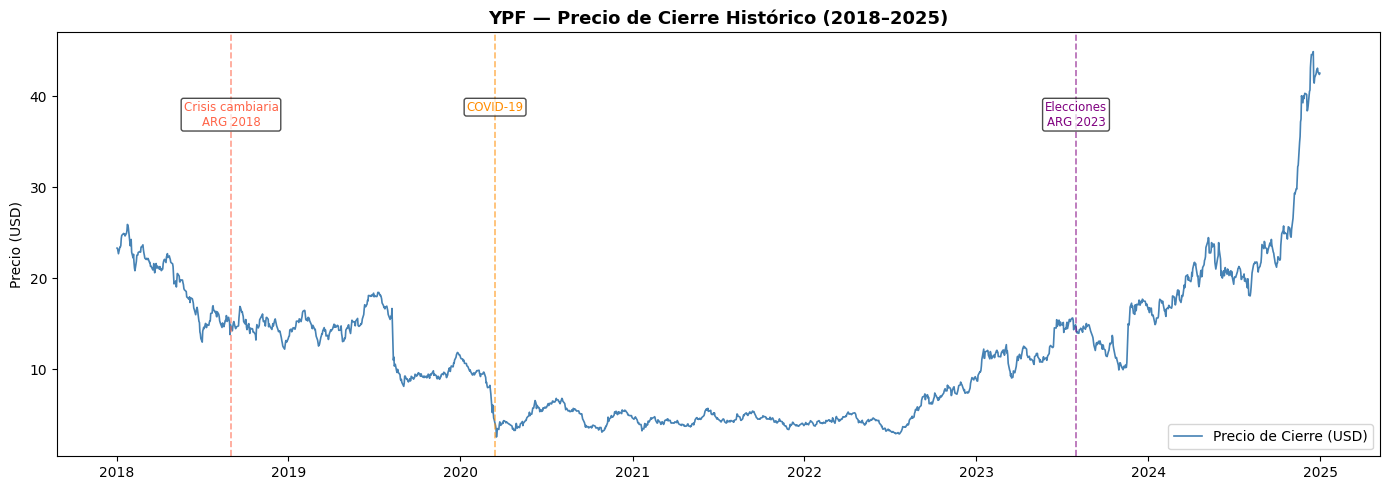

In [84]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='steelblue', linewidth=1.2, label='Precio de Cierre (USD)')

eventos = {
    '2018-09-01': ('Crisis cambiaria\nARG 2018', 'tomato'),
    '2020-03-15': ('COVID-19', 'darkorange'),
    '2023-08-01': ('Elecciones\nARG 2023', 'purple'),
}
for fecha, (texto, color) in eventos.items():
    ax.axvline(pd.Timestamp(fecha), color=color, linestyle='--', alpha=0.6, linewidth=1.2)
    ax.text(pd.Timestamp(fecha), df['Close'].max() * 0.88, texto,
            color=color, fontsize=8.5, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('YPF — Precio de Cierre Histórico (2018–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

La serie muestra una caída pronunciada en 2018 (crisis cambiaria), un piso en marzo de 2020 (inicio de la pandemia) y una recuperación posterior con alta volatilidad. La forma de la curva ya anticipa que la serie no será estacionaria.

---
## 2. Procesamiento de Señales

El precio de cierre de la acción puede modelarse como una señal discreta, ya que se observa únicamente en instantes separados de tiempo (días hábiles de mercado). Cada observación constituye una muestra de la señal, formando una secuencia temporal sobre la cual pueden aplicarse técnicas de procesamiento digital de señales.

Desde esta perspectiva, la señal tiene dos componentes superpuestos:

- **Tendencia** (baja frecuencia): el movimiento lento de mediano y largo plazo.
- **Ruido** (alta frecuencia): las fluctuaciones diarias que no aportan información sobre la tendencia.

El objetivo de esta sección es separar ambas componentes usando filtros y luego analizar el contenido frecuencial de la señal.

### 2.1 Suavizado: SMA y EMA como filtros de paso bajo

Las medias móviles son **filtros de paso bajo**: atenúan las componentes de alta frecuencia (ruido de corto plazo) y preservan las de baja frecuencia (tendencia). Son el equivalente financiero de un filtro de suavizado aplicado a una señal de audio o imagen.

**SMA (Simple Moving Average):** promedio aritmético uniforme de los últimos $n$ valores.

$$\text{SMA}_t = \frac{1}{n} \sum_{i=0}^{n-1} x_{t-i}$$

**EMA (Exponential Moving Average):** pondera exponencialmente más los valores recientes. Tiene menor retraso (*lag*) que la SMA ante cambios de tendencia debido a que asigna mayor peso a las observaciones recientes.

$$\text{EMA}_t = \alpha \cdot x_t + (1-\alpha) \cdot \text{EMA}_{t-1}, \quad \alpha = \frac{2}{n+1}$$

Usaremos ventanas de **20 días** (1 mes bursatil o 20 ruedas de mercado) y **60 días** (1 trimestre o 3 ruedas de 20 dias).

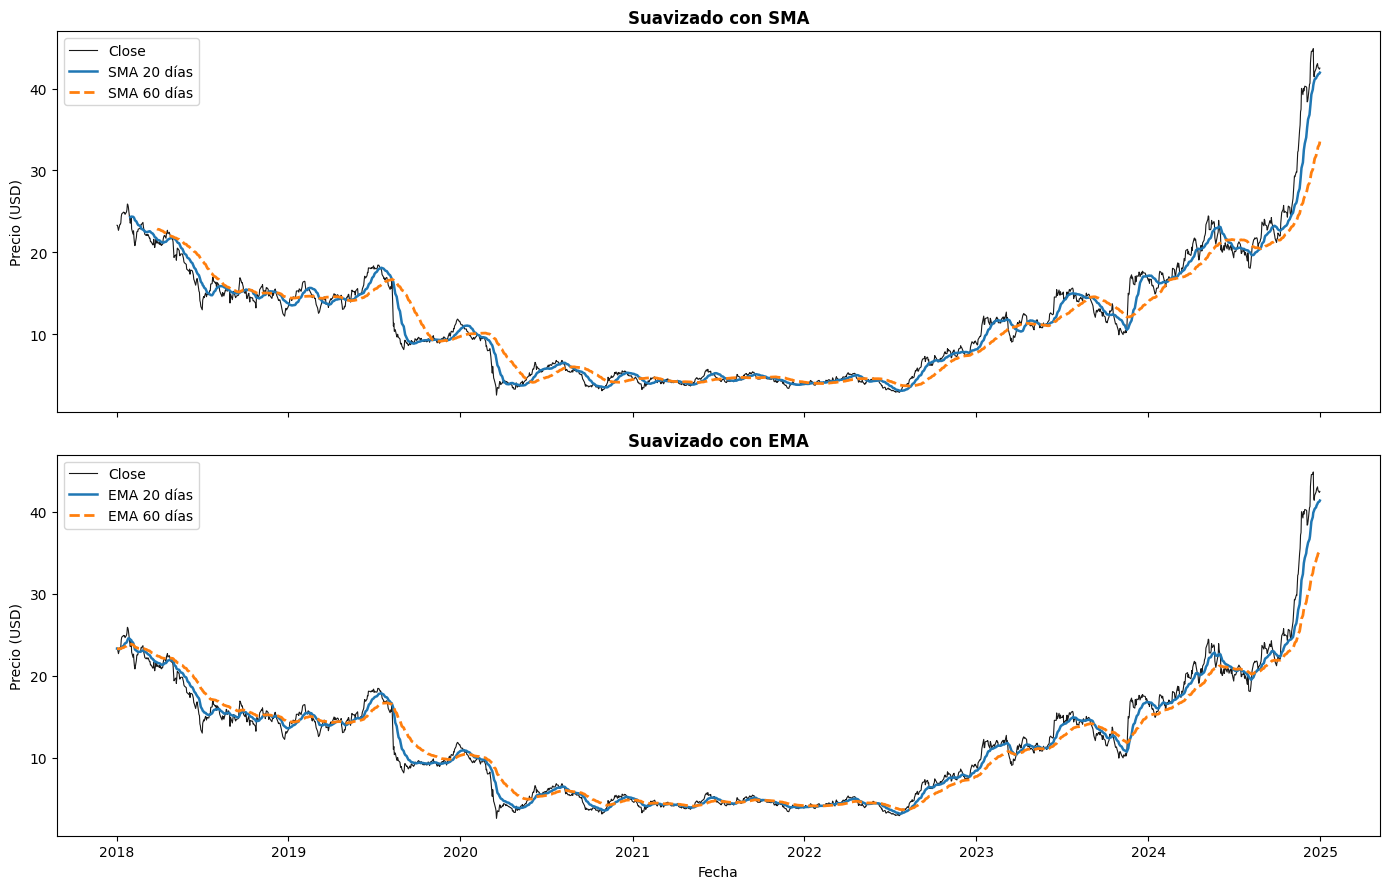

In [85]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_60'] = df['Close'].rolling(window=60).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_60'] = df['Close'].ewm(span=60, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, (col20, col60, titulo) in zip(axes, [
    ('SMA_20', 'SMA_60', 'SMA'),
    ('EMA_20', 'EMA_60', 'EMA')
]):
    ax.plot(df.index, df['Close'], color='black', linewidth=0.8, alpha=0.9, label='Close')
    ax.plot(df.index, df[col20], linewidth=1.8, label=f'{titulo} 20 días')
    ax.plot(df.index, df[col60], linewidth=2.0, linestyle='--', label=f'{titulo} 60 días')
    ax.set_title(f'Suavizado con {titulo}', fontweight='bold')
    ax.set_ylabel('Precio (USD)')
    ax.legend()

axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

Los resultados muestran que tanto SMA como EMA actúan como filtros de suavizado sobre la serie de precios. Las ventanas de 60 días producen una mayor atenuación de las fluctuaciones de corto plazo que las de 20 días, a costa de introducir un mayor retraso respecto a la señal original. Asimismo, las EMA siguen más de cerca los movimientos del precio que las SMA equivalentes, debido a la mayor ponderación asignada a las observaciones recientes. En todos los casos, los filtros permiten resaltar la tendencia general de la acción y facilitar su análisis visual.
En particular la EMA 60 muestra una tendencia alcista fuerte en los últimos años.

### Cruce de EMAs

Estos cruces permiten visualizar posibles cambios de tendencia en la serie de precios. Debido a que la EMA de corto plazo es más sensible a los cambios recientes, los cruces con la EMA de largo plazo pueden actuar como indicadores de cambio en la dirección general de la tendencia.

Se identifican señales alcistas cuando la EMA de 20 días cruza por encima de la EMA de 60 días y señales bajistas cuando ocurre el cruce inverso.

Mientras no se produzca un nuevo cruce entre las medias móviles, se considera que la tendencia previamente identificada permanece vigente. De esta manera, los cruces actúan como posibles puntos de cambio de tendencia, mientras que los períodos entre cruces representan fases de continuidad de la tendencia dominante (observar 2024 a 2025).

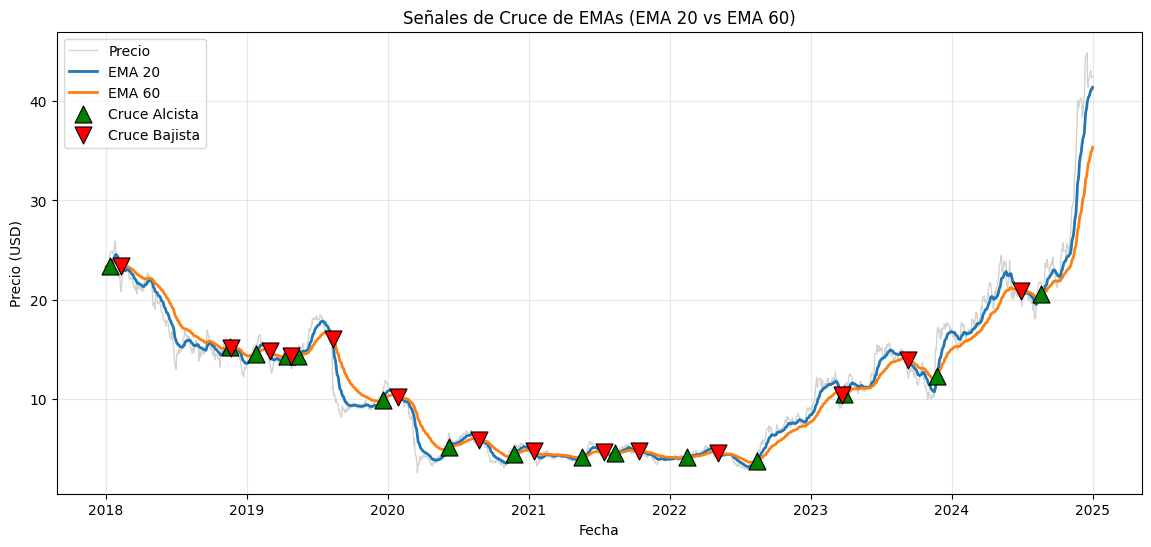

In [86]:
# Detectar cruces
df['Signal'] = np.where(df['EMA_20'] > df['EMA_60'], 1, 0)
df['Crossover'] = df['Signal'].diff()

bullish = df[df['Crossover'] == 1]
bearish = df[df['Crossover'] == -1]

# Graficar
plt.figure(figsize=(14,6))

plt.plot(df.index, df['Close'], color='lightgray', linewidth=1, label='Precio')
plt.plot(df.index, df['EMA_20'], linewidth=2, label='EMA 20')
plt.plot(df.index, df['EMA_60'], linewidth=2, label='EMA 60')

plt.scatter(
    bullish.index,
    bullish['EMA_20'],
    marker='^',
    s=150,
    color='green',
    edgecolors='black',
    linewidths=0.8,
    zorder=10,
    label='Cruce Alcista'
)

plt.scatter(
    bearish.index,
    bearish['EMA_20'],
    marker='v',
    s=150,
    color='red',
    edgecolors='black',
    linewidths=0.8,
    zorder=10,
    label='Cruce Bajista'
)

plt.title('Señales de Cruce de EMAs (EMA 20 vs EMA 60)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Al restar la SMA de la señal original se obtiene una componente residual que representa las fluctuaciones de corto plazo no capturadas por la tendencia. El análisis de esta componente permite identificar períodos de mayor volatilidad y cuantificar qué tan alejado se encuentra el precio respecto de su comportamiento promedio reciente.

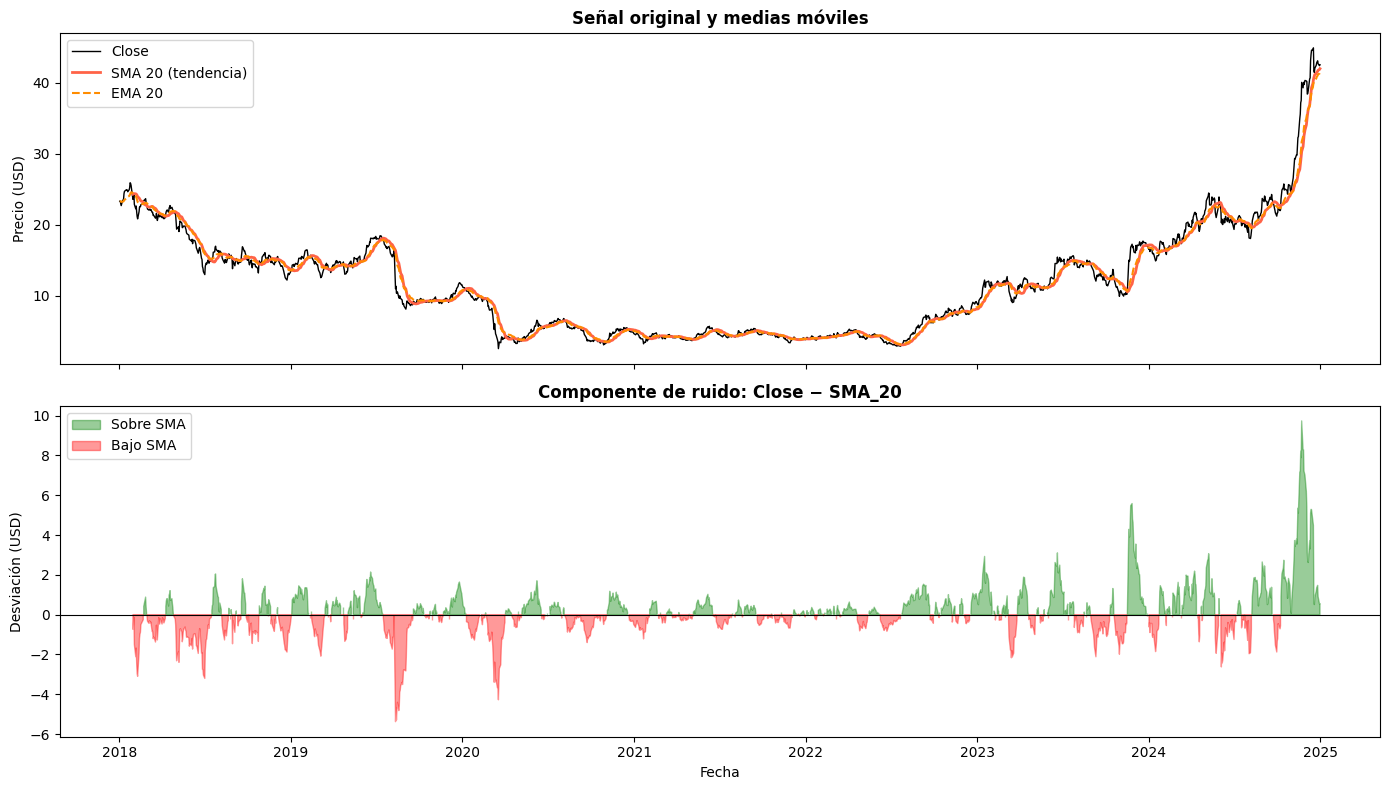

In [87]:
 # La diferencia entre la señal original y la SMA_20 es la componente de ruido
df['Ruido'] = df['Close'] - df['SMA_20']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['Close'], color='black', linewidth=1.0, label='Close')
axes[0].plot(df.index, df['SMA_20'], color='tomato', linewidth=2.0, label='SMA 20 (tendencia)')
axes[0].plot(df.index, df['EMA_20'], color='darkorange', linewidth=1.5, linestyle='--', label='EMA 20')
axes[0].set_title('Señal original y medias móviles', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend()

axes[1].fill_between(df.index, df['Ruido'], 0,
                     where=(df['Ruido'] >= 0), color='green', alpha=0.4, label='Sobre SMA')
axes[1].fill_between(df.index, df['Ruido'], 0,
                     where=(df['Ruido'] < 0),  color='red',   alpha=0.4, label='Bajo SMA')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Componente de ruido: Close − SMA_20', fontweight='bold')
axes[1].set_ylabel('Desviación (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observaciones:**

Se observa que la SMA y la EMA permiten aislar la tendencia general de la acción, mientras que la diferencia entre el precio y la SMA refleja las fluctuaciones de corto plazo. Las desviaciones más grandes se concentran en períodos de alta volatilidad, donde el precio se aleja significativamente de la tendencia estimada por la media móvil.

---
## 3. Análisis Temporal

En esta sección cambiamos de perspectiva: ya no analizamos el precio como una señal genérica, sino como una **serie temporal** con estructura de autocorrelación. Este análisis es un prerrequisito para cualquier modelo de forecasting.

### 3.1 Estacionariedad y Test ADF

Una serie temporal es **estacionaria** si sus propiedades estadísticas, como la media, la varianza y la autocovarianza, permanecen aproximadamente constantes a lo largo del tiempo. Intuitivamente, una serie estacionaria fluctúa alrededor de un mismo nivel sin presentar tendencias persistentes ni cambios sistemáticos en su variabilidad.

La estacionariedad es un requisito importante para muchos modelos clásicos de series temporales, como ARIMA y SARIMA, ya que estos modelos asumen que la estructura estadística de la serie no cambia con el tiempo. Cuando una serie presenta tendencia o cambios en su comportamiento, suele ser necesario transformarla antes de aplicar estos modelos.

Para evaluar esta propiedad se utiliza el **test Augmented Dickey-Fuller (ADF)**, que permite detectar la presencia de una **raíz unitaria**. Una raíz unitaria indica que los efectos de perturbaciones aleatorias persisten en el tiempo y no se disipan. Como consecuencia, la serie no presenta una media constante alrededor de la cual oscile y se considera no estacionaria.

El test plantea las siguientes hipótesis:

- $H_0$: la serie posee una raíz unitaria (no es estacionaria).
- $H_1$: la serie es estacionaria.

Se rechaza $H_0$ cuando el estadístico ADF es menor que el valor crítico correspondiente o, de forma equivalente, cuando el p-valor es inferior a 0.05.

In [88]:
def mostrar_adf(serie, nombre):
    """Ejecuta el test ADF y muestra los resultados de forma legible."""
    res = adfuller(serie.dropna(), autolag='AIC')
    print(f"  Test ADF — {nombre}")
    print(f"  Estadístico : {res[0]:.4f}")
    print(f"  p-valor     : {res[1]:.6f}")
    print(f"  Lags usados : {res[2]}")
    for nivel, val in res[4].items():
        marca = " ← estadístico más negativo ✓" if res[0] < val else ""
        print(f"  Valor crítico {nivel}: {val:.4f}{marca}")
    if res[1] < 0.05:
        print("  → Conclusión: p < 0.05. Se RECHAZA H₀. La serie ES estacionaria.")
    else:
        print("  → Conclusión: p ≥ 0.05. NO se rechaza H₀. La serie NO es estacionaria.")
    print()
    return res

serie_original = df['Close'].dropna()

print("=" * 55)
res_original = mostrar_adf(serie_original, "Precio de Cierre (nivel)")

  Test ADF — Precio de Cierre (nivel)
  Estadístico : 1.3266
  p-valor     : 0.996754
  Lags usados : 5
  Valor crítico 1%: -3.4341
  Valor crítico 5%: -2.8632
  Valor crítico 10%: -2.5676
  → Conclusión: p ≥ 0.05. NO se rechaza H₀. La serie NO es estacionaria.



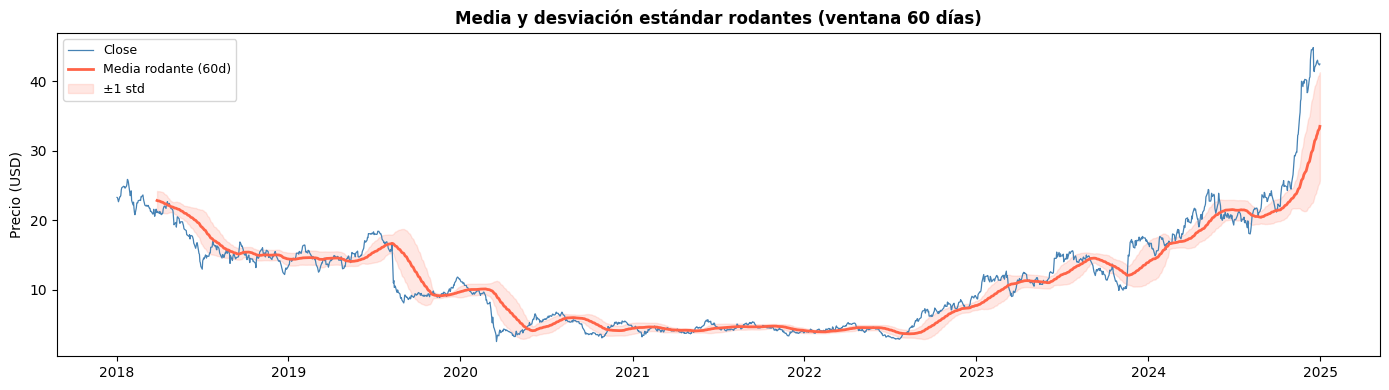

In [89]:
# Visualización de media y varianza rodantes para confirmar visualmente
media_rodante = serie_original.rolling(60).mean()
std_rodante   = serie_original.rolling(60).std()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(serie_original.index, serie_original.values, color='steelblue', linewidth=0.9, label='Close')
ax.plot(serie_original.index, media_rodante, color='tomato', linewidth=2.0, label='Media rodante (60d)')
ax.fill_between(serie_original.index,
                media_rodante - std_rodante, media_rodante + std_rodante,
                alpha=0.15, color='tomato', label='±1 std')
ax.set_title('Media y desviación estándar rodantes (ventana 60 días)', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

La Figura muestra la media rodante y la desviación estándar calculadas sobre ventanas móviles de 60 días. La media rodante representa el promedio de los últimos 60 valores de la serie en cada instante y permite observar cómo evoluciona su nivel promedio a lo largo del tiempo. Se observa que tanto la media como la variabilidad cambian significativamente durante el período analizado, lo que constituye evidencia visual de que la serie no es estacionaria y coincide con los resultados obtenidos mediante el test ADF.

### Diferenciación de primer orden

Dado que la serie de precios no es estacionaria, se aplica una **diferenciación de primer orden**, definida como:

$$
\Delta P_t = P_t - P_{t-1}
$$

Esta transformación calcula la diferencia entre el precio actual y el del período anterior. Se denomina *de primer orden* porque la diferencia se calcula una sola vez utilizando observaciones consecutivas. Si la serie siguiera sin ser estacionaria, podría aplicarse una segunda diferenciación sobre la serie resultante.

Al realizar esta operación, la información sobre la tendencia de largo plazo se reduce significativamente y la serie pasa a representar las variaciones diarias del precio en lugar de sus valores absolutos. Como consecuencia, suele obtenerse una serie que oscila alrededor de un nivel aproximadamente constante, condición necesaria para aplicar modelos como ARIMA o SARIMA.

  Test ADF — Primera diferencia (d=1)
  Estadístico : -18.2285
  p-valor     : 0.000000
  Lags usados : 4
  Valor crítico 1%: -3.4341 ← estadístico más negativo ✓
  Valor crítico 5%: -2.8632 ← estadístico más negativo ✓
  Valor crítico 10%: -2.5676 ← estadístico más negativo ✓
  → Conclusión: p < 0.05. Se RECHAZA H₀. La serie ES estacionaria.



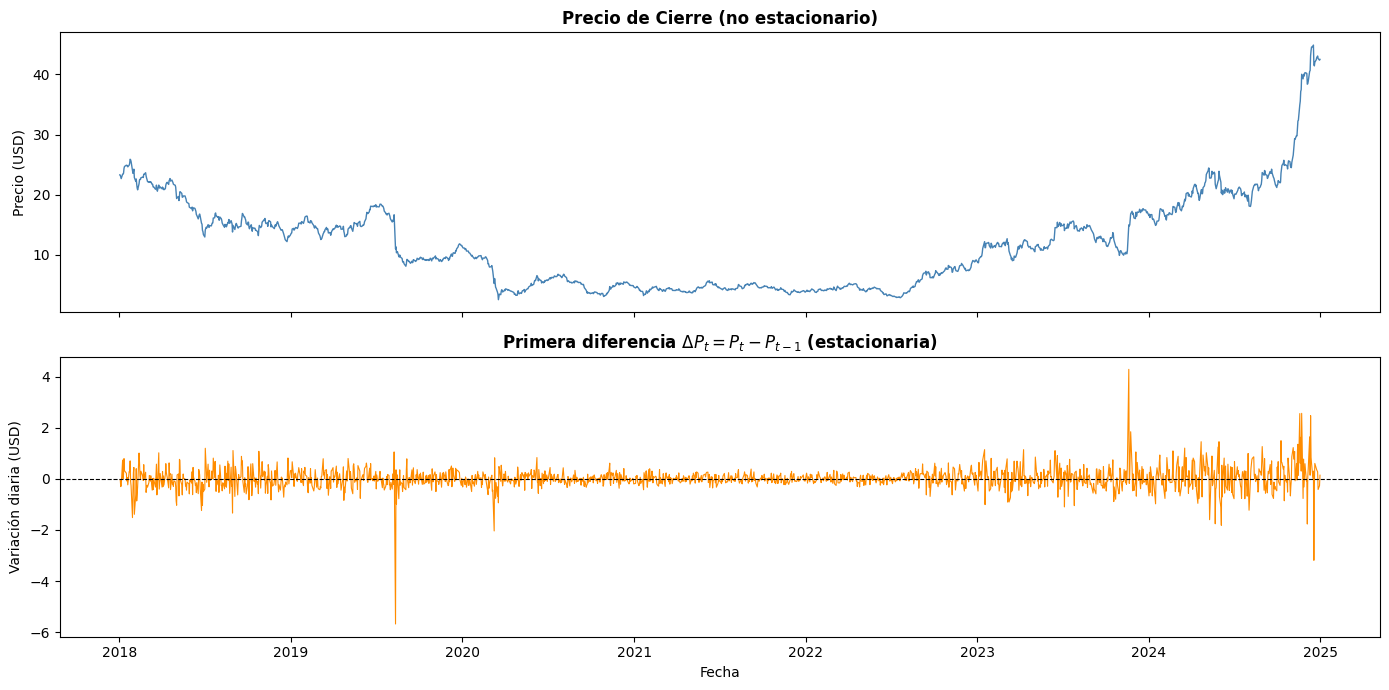

In [90]:
df['Close_diff1'] = df['Close'].diff(1)
serie_diff1 = df['Close_diff1'].dropna()

print("=" * 55)
res_diff = mostrar_adf(serie_diff1, "Primera diferencia (d=1)")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(serie_original.index, serie_original.values, color='steelblue', linewidth=1.0)
axes[0].set_title('Precio de Cierre (no estacionario)', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')

axes[1].plot(serie_diff1.index, serie_diff1.values, color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title(r'Primera diferencia $\Delta P_t = P_t - P_{t-1}$ (estacionaria)', fontweight='bold')
axes[1].set_ylabel('Variación diaria (USD)')
axes[1].set_xlabel('Fecha')
plt.tight_layout()
plt.show()

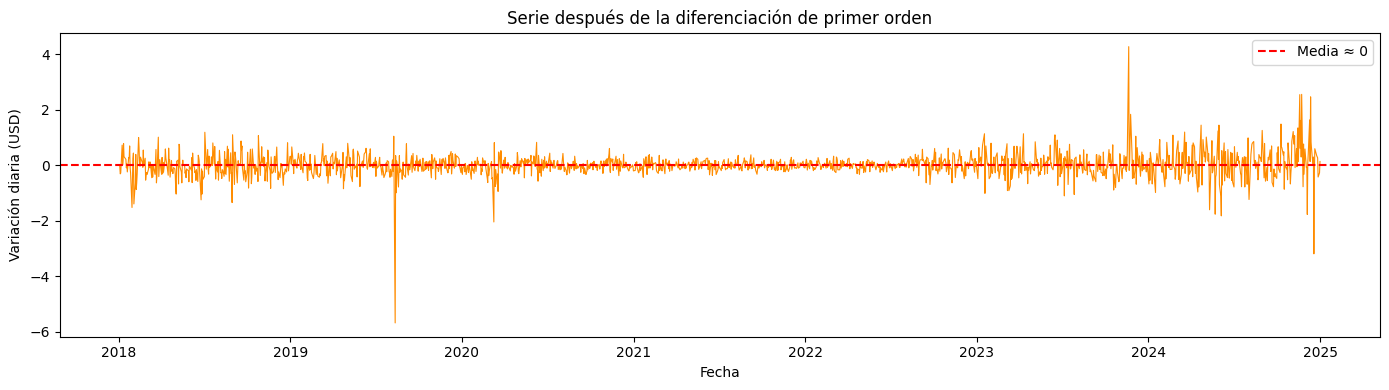

In [91]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(serie_diff1.index, serie_diff1.values,
        color='darkorange', linewidth=0.8)

ax.axhline(0, color='red', linestyle='--', linewidth=1.5,
           label='Media ≈ 0')

ax.set_title('Serie después de la diferenciación de primer orden')
ax.set_ylabel('Variación diaria (USD)')
ax.set_xlabel('Fecha')
ax.legend()

plt.tight_layout()
plt.show()

Tras aplicar la diferenciación de primer orden, la serie deja de presentar una tendencia evidente y pasa a oscilar alrededor de cero. Este comportamiento sugiere una mejora significativa respecto de la serie original en términos de estacionariedad. La conclusión se confirma mediante el test ADF, que rechaza la hipótesis nula de presencia de raíz unitaria (p < 0.05).

**La serie diferenciada es simplemente un gráfico de las diferencias entre días consecutivos.**

### 3.2 División temporal y preparación para Forecasting

Dividimos la serie en **80% entrenamiento / 20% prueba**, respetando el orden cronológico. Una división aleatoria filtrarías información del futuro hacia el pasado (*data leakage*), invalidando la evaluación.

Ambos modelos trabajarán sobre el **precio de cierre sin diferenciar**:
- **SARIMA** incorpora internamente el parámetro $d$, que indica cuántas veces debe diferenciarse la serie para volverla estacionaria antes de ajustar el modelo. En este trabajo se utiliza $d=1$, ya que una única diferenciación fue suficiente para que la serie superara el test ADF de estacionariedad.
- **LSTM** no requiere estacionariedad, pero sí normalización de los datos.


Entrenamiento : 1408 obs  (2018-01-02 → 2023-08-07)
Test          : 353 obs  (2023-08-08 → 2024-12-31)


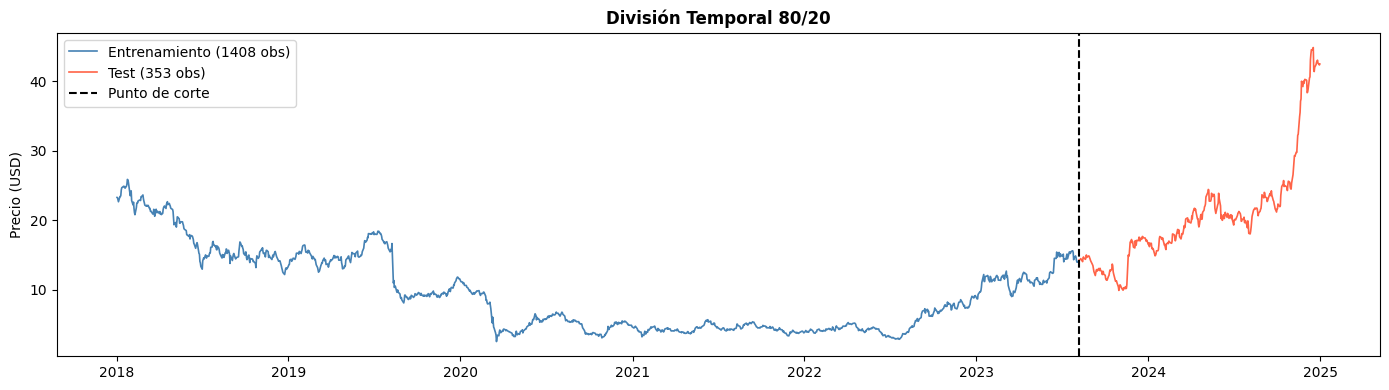

In [92]:
serie_precios = df['Close'].dropna()
split_idx     = int(len(serie_precios) * 0.80)
train_series  = serie_precios.iloc[:split_idx]
test_series   = serie_precios.iloc[split_idx:]

print(f"Entrenamiento : {len(train_series)} obs  ({train_series.index[0].date()} → {train_series.index[-1].date()})")
print(f"Test          : {len(test_series)} obs  ({test_series.index[0].date()} → {test_series.index[-1].date()})")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train_series.index, train_series.values, color='steelblue', linewidth=1.2,
        label=f'Entrenamiento ({len(train_series)} obs)')
ax.plot(test_series.index,  test_series.values,  color='tomato',    linewidth=1.2,
        label=f'Test ({len(test_series)} obs)')
ax.axvline(test_series.index[0], color='black', linestyle='--', linewidth=1.5, label='Punto de corte')
ax.set_title('División Temporal 80/20', fontweight='bold')
ax.set_ylabel('Precio (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### Convertimos a retornos logaritmos los datos de entrenamiento y testeo
Antes del entrenamiento, los precios de cierre se transformaron en retornos logarítmicos, que representan la variación relativa entre dos días consecutivos utilizando el logaritmo natural. Esta transformación reduce el efecto de la tendencia presente en los precios, genera una serie más estable y facilita el aprendizaje de los modelos. Además, permite que tanto SARIMA como LSTM modelen las variaciones del precio en lugar de los valores absolutos.

In [93]:
# Calcular retornos logarítmicos para ambos modelos
df['LogReturn'] = np.log(df['Close'] / df['Close'].shift(1))
log_returns = df['LogReturn'].dropna()

# Split de log-retornos alineado con el split de precios
train_log = log_returns.loc[train_series.index[1]:train_series.index[-1]]
test_log  = log_returns.loc[test_series.index[0]:test_series.index[-1]]

#print(f"Log-Retornos train: {len(train_log)}, test: {len(test_log)}")
train_log.describe().round(10)


count    1407.000000
mean       -0.000365
std         0.038232
min        -0.416315
25%        -0.020237
50%         0.000000
75%         0.019278
max         0.171236
Name: LogReturn, dtype: float64

La media de los retornos logarítmicos es cercana a cero (-0,0365%), mientras que la mediana es igual a cero, indicando que la distribución se encuentra centrada alrededor de variaciones diarias muy pequeñas. La desviación estándar (3,82%) refleja la volatilidad característica de la acción de YPF. Asimismo, los valores extremos muestran la existencia de jornadas con movimientos significativos del precio.

---
## 4. Forecasting

Comparamos dos enfoques con filosofías distintas:

- **SARIMA**: modelo estadístico lineal clásico, basado en autocorrelaciones. Interpretable y con fundamento matemático explícito.
- **LSTM**: red neuronal recurrente capaz de aprender dependencias temporales no lineales. Menos interpretable pero más flexible.

### Corrección importante

Las métricas de evaluación y la tabla comparativa se encuentran en la sección **5. Evaluación**, más adelante en este notebook.


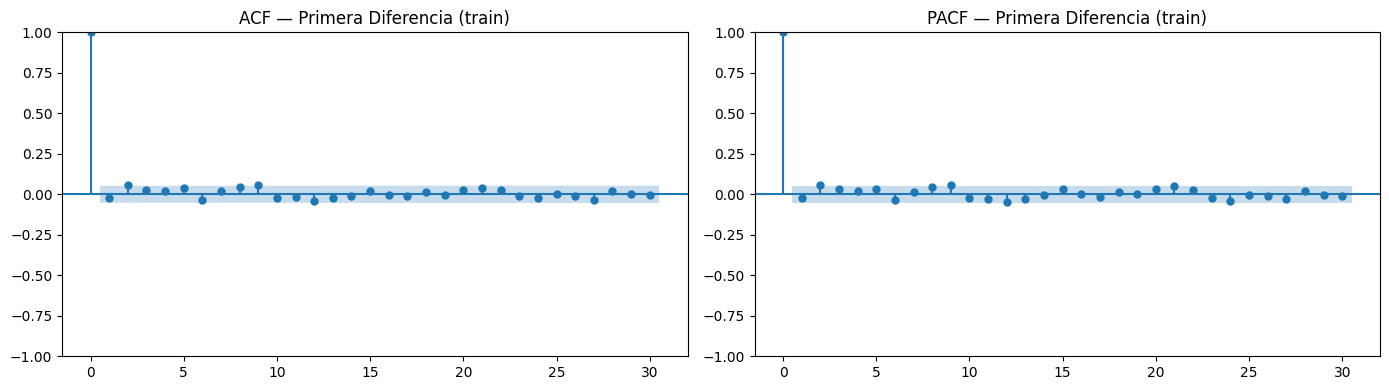

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
serie_diff_train = train_series.diff(1).dropna()

plot_acf(serie_diff_train,  lags=30, ax=axes[0], title='ACF — Primera Diferencia (train)')
plot_pacf(serie_diff_train, lags=30, ax=axes[1], title='PACF — Primera Diferencia (train)', method='ywm')

plt.tight_layout()
plt.show()

Los parámetros \(p\) y \(q\) se seleccionaron a partir del análisis de los gráficos ACF y PACF de la serie diferenciada. Dado que no se observaron patrones fuertes, se optó por utilizar valores bajos (\(p=1\) y \(q=1\)) para construir un modelo simple capaz de capturar posibles dependencias temporales residuales.


In [95]:
print("Entrenando SARIMA(1,0,1)(1,0,0)[5] sobre log-retornos...")

modelo_sarima = SARIMAX(
    train_log,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultado_sarima = modelo_sarima.fit(disp=False)
print(f"AIC: {resultado_sarima.aic:.2f} | BIC: {resultado_sarima.bic:.2f}")
print(resultado_sarima.summary().tables[1])

# Predicción ONE-STEP AHEAD via apply()
res_full = resultado_sarima.apply(log_returns)
sarima_log_pred = res_full.fittedvalues.loc[test_series.index]

# Convertir log-retornos a precios: P_t = P_{t-1} * exp(r_hat)
sarima_price_pred = test_series.shift(1).fillna(train_series.iloc[-1]) * np.exp(sarima_log_pred)

print(f"\nPredicciones SARIMA (primeros 5):")
print(sarima_price_pred.head().round(2))


Entrenando SARIMA(1,0,1)(1,0,0)[5] sobre log-retornos...
AIC: -5163.22 | BIC: -5142.24
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8473      0.091      9.310      0.000       0.669       1.026
ma.L1         -0.8133      0.100     -8.168      0.000      -1.008      -0.618
ar.S.L5        0.0043      0.020      0.212      0.832      -0.035       0.044
sigma2         0.0015   1.86e-05     78.425      0.000       0.001       0.001

Predicciones SARIMA (primeros 5):
Date
2023-08-08    13.93
2023-08-09    14.32
2023-08-10    14.33
2023-08-11    14.39
2023-08-14    14.51
dtype: float64


### Análisis de resultados SARIMA

**Conclusión:** El modelo **SARIMA(1,0,1)(1,0,0)[5]** permitió incorporar tanto dependencias temporales de corto plazo como una posible estacionalidad semanal de cinco días hábiles. Las predicciones obtenidas muestran un comportamiento estable, con valores cercanos a los últimos precios observados. Si bien los coeficientes autoregresivo y de media móvil no resultaron estadísticamente significativos, el modelo constituye una aproximación interpretable y útil para el análisis de series financieras, sirviendo como referencia para comparar con modelos más complejos.

### 4.2 Modelo LSTM

Las redes **LSTM** (Long Short-Term Memory) son redes neuronales recurrentes diseñadas para trabajar con datos secuenciales, como series temporales. A diferencia de las redes neuronales tradicionales, poseen celdas de memoria y puertas de entrada, olvido y salida que les permiten aprender qué información del pasado es relevante conservar y cuál descartar. Gracias a esto, son capaces de capturar dependencias de largo plazo en la serie.

**Preparación de datos:** para entrenar la red, se construyen **ventanas deslizantes** de tamaño \(w\). Una ventana deslizante consiste en tomar una secuencia de los últimos \(w\) valores de la serie como entrada para predecir el siguiente valor. Formalmente, para cada instante \(t\), el modelo recibe la secuencia \([P_{t-w}, \ldots, P_{t-1}]\) y predice \(P_t\). Luego, la ventana se desplaza un paso hacia adelante y el proceso se repite.

Por ejemplo, si \(w=20\), el modelo utiliza los precios de los últimos 20 días hábiles para predecir el precio del día siguiente. El parámetro \(w\) determina cuánta información histórica tiene disponible la red: valores pequeños pueden perder patrones relevantes, mientras que valores muy grandes aumentan la complejidad del modelo y el riesgo de sobreajuste. En este trabajo se utilizó \(w=20\) días.

**Normalización:** antes del entrenamiento, el precio se escala al rango \([0,1]\) utilizando `MinMaxScaler`. Para evitar filtrar información del futuro, el scaler se ajusta únicamente sobre el conjunto de entrenamiento y luego se aplica al conjunto de prueba.

La construcción de ventanas deslizantes de tamaño \(w=20\) generó 1388 secuencias para entrenamiento y 353 para prueba. Cada secuencia posee una dimensión \((20,1)\), donde los 20 pasos temporales corresponden a los precios de los últimos 20 días hábiles y la única característica considerada es el precio de cierre. El objetivo asociado a cada secuencia es predecir el precio del día siguiente.

Preprocesamiento

In [96]:
# LSTM sobre LOG-RETORNOS
scaler_lstm = MinMaxScaler(feature_range=(0, 1))

train_lstm_scaled = scaler_lstm.fit_transform(train_log.values.reshape(-1, 1))
test_lstm_scaled  = scaler_lstm.transform(test_log.values.reshape(-1, 1))

def crear_secuencias(data, ventana):
    X, y = [], []
    for i in range(ventana, len(data)):
        X.append(data[i-ventana:i, 0])
        y.append(data[i, 0])
    return np.array(X).reshape(-1, ventana, 1), np.array(y)


Funciones para entrenar al modelo

In [97]:
def entrenar_lstm(ventana, deep=False):

    X_train, y_train = crear_secuencias(train_lstm_scaled, ventana)

    if deep:
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(ventana, 1)),
            Dropout(0.3),
            LSTM(32),
            Dropout(0.3),
            Dense(16, activation='relu'),
            Dense(1)
        ])
    else:
        model = Sequential([
            LSTM(64, input_shape=(ventana, 1)),
            Dropout(0.2),
            Dense(1)
        ])

    model.compile(optimizer='adam', loss='mse')

    model.fit(
        X_train, y_train,
        epochs=80,
        batch_size=32,
        validation_split=0.1,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
        verbose=0
    )

    return model

Entrenamos los modelos

In [98]:
print("Entrenando modelo 20...")
model_20 = entrenar_lstm(ventana=20, deep=False)

print("Entrenando modelo 60...")
model_60 = entrenar_lstm(ventana=60, deep=False)

print("Entrenando modelo 60+...")
model_60_plus = entrenar_lstm(ventana=60, deep=True)

Entrenando modelo 20...
Entrenando modelo 60...
Entrenando modelo 60+...


Funcion para evaluar los modelos LSTM

In [99]:
def predict_lstm_one_step(model, ventana, train_scaled, test_scaled, scaler):
    """Predicción one-step ahead: usa el valor real del paso anterior como contexto."""
    preds_scaled = []
    # Primeros 'ventana' valores de test usan cola del train como contexto
    context = np.concatenate([train_scaled[-ventana:], test_scaled], axis=0)

    for i in range(ventana, len(context)):
        x_input = context[i - ventana:i].reshape(1, ventana, 1)
        yhat = model.predict(x_input, verbose=0)[0][0]
        preds_scaled.append(yhat)

    preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
    return preds


# Comparación de modelos LSTM

Se entrenaron tres modelos LSTM con diferentes capacidades de memoria y complejidad:

---

## LSTM 20 (memoria corta)
- Usa solo los últimos 20 días
- Captura patrones locales recientes
- Menos propenso a overfitting
- Puede reaccionar mejor a cambios rápidos

---

## LSTM 60 (memoria media)
- Usa los últimos 60 días
- Captura tendencias más largas
- Más estabilidad en series suaves
- Puede perder sensibilidad a cambios bruscos

---

## LSTM 60+ (modelo profundo)
- Arquitectura más compleja (2 capas LSTM)
- Mayor capacidad de aprendizaje no lineal
- Mayor riesgo de overfitting
- Puede capturar estructuras más complejas

---

## Nota importante
Todos los modelos utilizan forecast autoregresivo:
- cada predicción se alimenta de la anterior
- no se usan valores reales del test
- comparación justa entre modelos

### Selección de hiperparámetros

Los hiperparámetros de la red LSTM fueron seleccionados a partir de valores comúnmente utilizados en la práctica y configuraciones estándar reportadas en la literatura. Posteriormente, se verificó que dichas configuraciones produjeran un entrenamiento estable y un desempeño adecuado sobre el conjunto de validación.

Veamos algunos resultados

In [100]:
# =============================
# PREDICCIÓN ONE-STEP AHEAD
# =============================

pred_20  = predict_lstm_one_step(model_20, 20, train_lstm_scaled, test_lstm_scaled, scaler_lstm)
pred_60  = predict_lstm_one_step(model_60, 60, train_lstm_scaled, test_lstm_scaled, scaler_lstm)
pred_60p = predict_lstm_one_step(model_60_plus, 60, train_lstm_scaled, test_lstm_scaled, scaler_lstm)

pred_20_series  = pd.Series(pred_20,  index=test_series.index)
pred_60_series  = pd.Series(pred_60,  index=test_series.index)
pred_60p_series = pd.Series(pred_60p, index=test_series.index)

print("LSTM 20 (one-step)")
print(pred_20_series.describe())

print("\nLSTM 60 (one-step)")
print(pred_60_series.describe())

print("\nLSTM 60+ (one-step)")
print(pred_60p_series.describe())

LSTM 20 (one-step)
count    353.000000
mean       0.001259
std        0.004072
min       -0.008190
25%       -0.001121
50%        0.000729
75%        0.003088
max        0.020849
dtype: float64

LSTM 60 (one-step)
count    353.000000
mean       0.000365
std        0.007774
min       -0.016921
25%       -0.004429
50%       -0.000398
75%        0.004077
max        0.036004
dtype: float64

LSTM 60+ (one-step)
count    353.000000
mean      -0.020034
std        0.003409
min       -0.026545
25%       -0.022467
50%       -0.020353
75%       -0.018493
max       -0.005565
dtype: float64


## 5. Evaluación

Evaluamos el desempeño de los modelos utilizando dos métricas complementarias, expresadas en USD para facilitar la interpretación:

- **RMSE (Root Mean Squared Error):** mide la magnitud promedio de los errores, penalizando más fuertemente los errores grandes debido al término cuadrático. Se define como:

  $$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2}$$

- **MAE (Mean Absolute Error):** calcula el promedio de los errores absolutos y es menos sensible a valores atípicos que el RMSE. Se define como:

  $$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|\hat{y}_i - y_i|$$


In [101]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_real = test_series.values

# -----------------------------
# SARIMA (predictions already converted to prices)
# -----------------------------
rmse_sarima = np.sqrt(mean_squared_error(y_real, sarima_price_pred.values))
mae_sarima  = mean_absolute_error(y_real, sarima_price_pred.values)

# -----------------------------
# LSTM predictions are in log-returns → convert to prices
# -----------------------------
ultimo_precio_train = train_series.iloc[-1]
precios_shift = test_series.shift(1).fillna(ultimo_precio_train)

lstm_20_price  = precios_shift * np.exp(pred_20_series)
lstm_60_price  = precios_shift * np.exp(pred_60_series)
lstm_60p_price = precios_shift * np.exp(pred_60p_series)

rmse_lstm_20  = np.sqrt(mean_squared_error(y_real, lstm_20_price))
mae_lstm_20   = mean_absolute_error(y_real, lstm_20_price)
rmse_lstm_60  = np.sqrt(mean_squared_error(y_real, lstm_60_price))
mae_lstm_60   = mean_absolute_error(y_real, lstm_60_price)
rmse_lstm_60p = np.sqrt(mean_squared_error(y_real, lstm_60p_price))
mae_lstm_60p  = mean_absolute_error(y_real, lstm_60p_price)

# -----------------------------
# TABLA COMPARATIVA
# -----------------------------
print(f"{'Modelo':<28} {'RMSE (USD)':>12} {'MAE (USD)':>12}")
print("-" * 55)
print(f"{'SARIMA(1,0,1)(1,0,0)[5]':<28} {rmse_sarima:>12.3f} {mae_sarima:>12.3f}")
print(f"{'LSTM 20':<28} {rmse_lstm_20:>12.3f} {mae_lstm_20:>12.3f}")
print(f"{'LSTM 60':<28} {rmse_lstm_60:>12.3f} {mae_lstm_60:>12.3f}")
print(f"{'LSTM 60+ (deep)':<28} {rmse_lstm_60p:>12.3f} {mae_lstm_60p:>12.3f}")


Modelo                         RMSE (USD)    MAE (USD)
-------------------------------------------------------
SARIMA(1,0,1)(1,0,0)[5]             0.646        0.446
LSTM 20                             0.647        0.449
LSTM 60                             0.659        0.462
LSTM 60+ (deep)                     0.817        0.600


### Sarima Prediccion Vs. Real

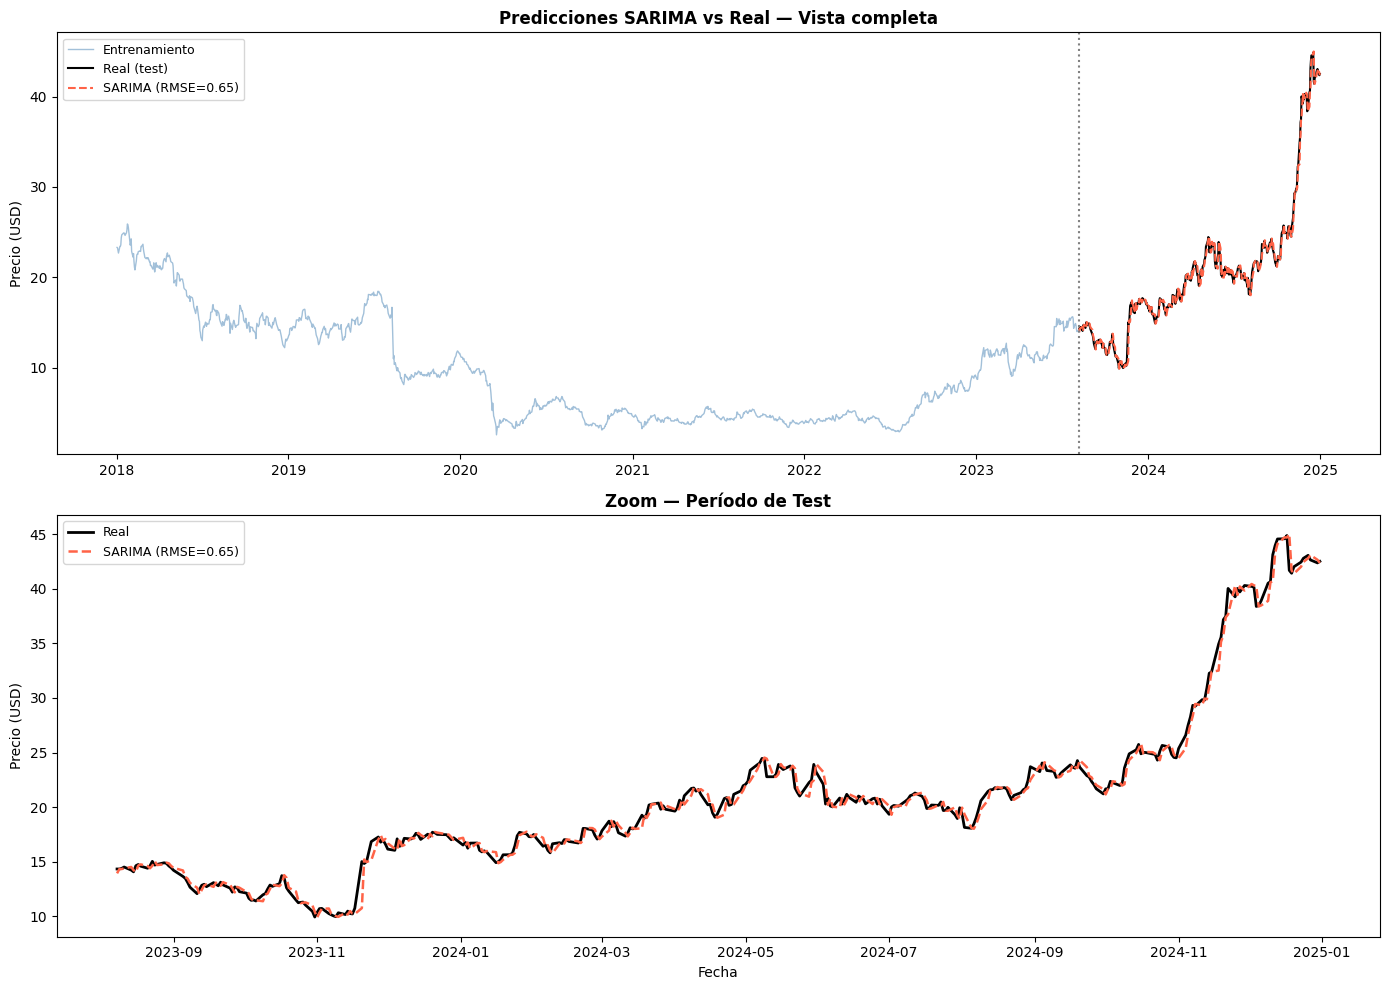

In [102]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Vista completa
axes[0].plot(train_series.index, train_series.values,
             color='steelblue', linewidth=1.0, alpha=0.5, label='Entrenamiento')
axes[0].plot(test_series.index, test_series.values,
             color='black', linewidth=1.5, label='Real (test)')
axes[0].plot(sarima_price_pred.index, sarima_price_pred.values,
             color='tomato', linewidth=1.5, linestyle='--',
             label=f'SARIMA (RMSE={rmse_sarima:.2f})')
axes[0].axvline(test_series.index[0], color='gray', linestyle=':', linewidth=1.5)
axes[0].set_title('Predicciones SARIMA vs Real — Vista completa', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend(fontsize=9)

# Zoom test
axes[1].plot(test_series.index, test_series.values,
             color='black', linewidth=2.0, label='Real')
axes[1].plot(sarima_price_pred.index, sarima_price_pred.values,
             color='tomato', linewidth=1.8, linestyle='--',
             label=f'SARIMA (RMSE={rmse_sarima:.2f})')
axes[1].set_title('Zoom — Período de Test', fontweight='bold')
axes[1].set_ylabel('Precio (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


# LSTM Prediccion Vs. Real

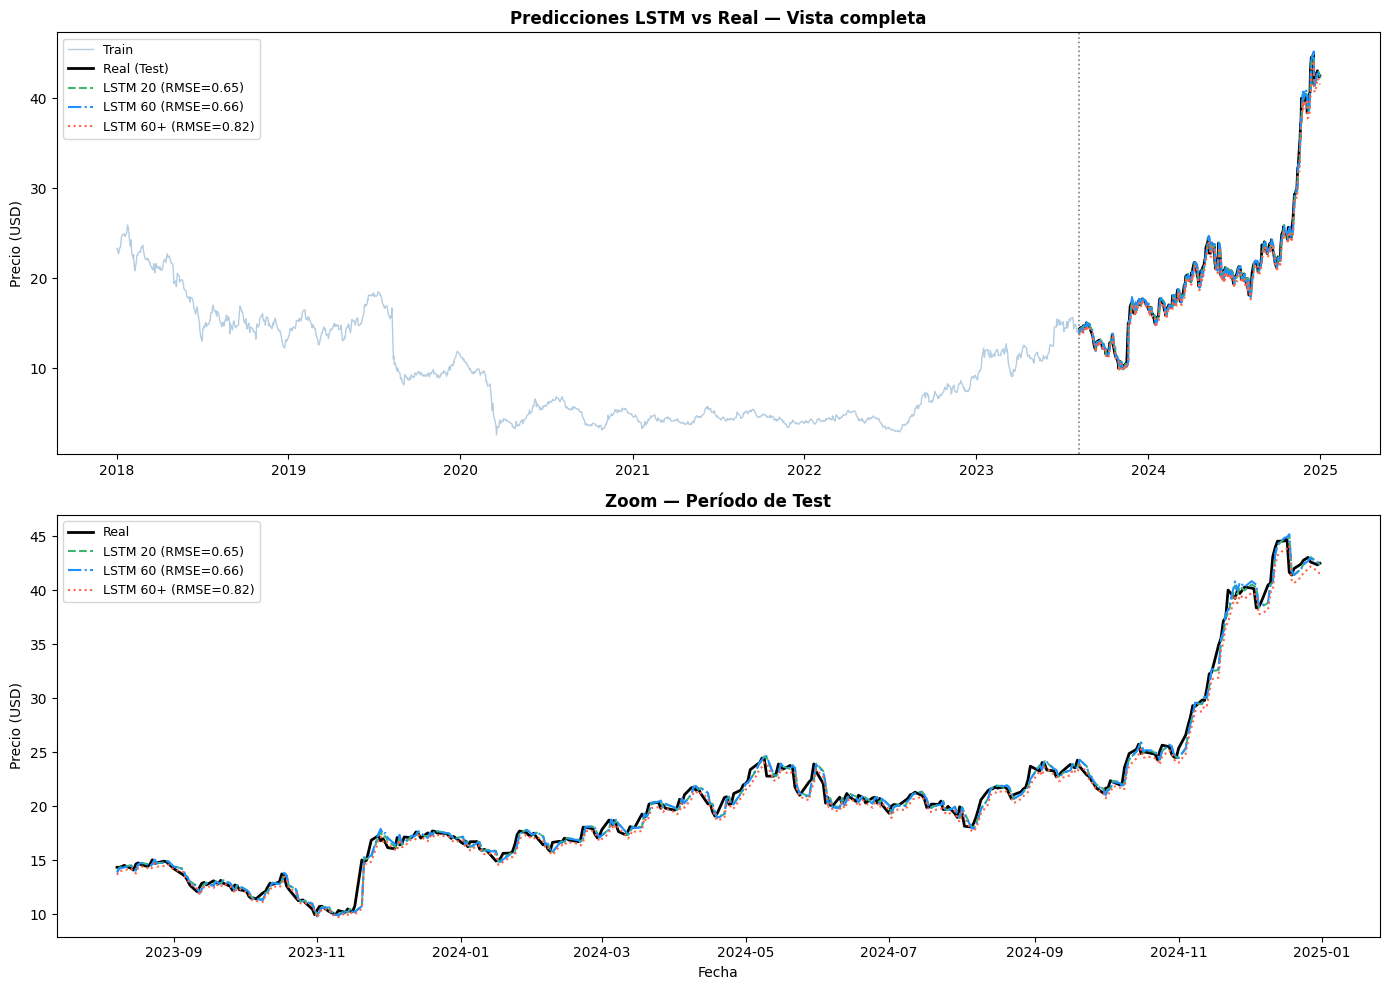

In [103]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14, 10))


# VISTA COMPLETA

# Train
axes[0].plot(train_series.index, train_series.values,
             color='steelblue', linewidth=1.0, alpha=0.4,
             label='Train')

# Test real
axes[0].plot(test_series.index, y_real,
             color='black', linewidth=2.0,
             label='Real (Test)')

# Predicciones LSTM
axes[0].plot(test_series.index, lstm_20_price,
             color='mediumseagreen', linewidth=1.5, linestyle='--',
             label=f'LSTM 20 (RMSE={rmse_lstm_20:.2f})')

axes[0].plot(test_series.index, lstm_60_price,
             color='dodgerblue', linewidth=1.5, linestyle='-.',
             label=f'LSTM 60 (RMSE={rmse_lstm_60:.2f})')

axes[0].plot(test_series.index, lstm_60p_price,
             color='tomato', linewidth=1.5, linestyle=':',
             label=f'LSTM 60+ (RMSE={rmse_lstm_60p:.2f})')

# Separación train/test
axes[0].axvline(test_series.index[0],
                color='gray', linestyle=':', linewidth=1.2)

axes[0].set_title('Predicciones LSTM vs Real — Vista completa', fontweight='bold')
axes[0].set_ylabel('Precio (USD)')
axes[0].legend(fontsize=9)

# ZOOM TEST

axes[1].plot(test_series.index, test_series.values,
             color='black', linewidth=2.0, label='Real')

axes[1].plot(test_series.index, lstm_20_price,
             color='mediumseagreen', linewidth=1.5, linestyle='--',
             label=f'LSTM 20 (RMSE={rmse_lstm_20:.2f})')

axes[1].plot(test_series.index, lstm_60_price,
             color='dodgerblue', linewidth=1.5, linestyle='-.',
             label=f'LSTM 60 (RMSE={rmse_lstm_60:.2f})')

axes[1].plot(test_series.index, lstm_60p_price,
             color='tomato', linewidth=1.5, linestyle=':',
             label=f'LSTM 60+ (RMSE={rmse_lstm_60p:.2f})')

axes[1].set_title('Zoom — Período de Test', fontweight='bold')
axes[1].set_ylabel('Precio (USD)')
axes[1].set_xlabel('Fecha')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Conclusiones

### ¿Qué aportó el procesamiento de señales?

Las medias móviles permitieron separar la tendencia del ruido de corto plazo y evidenciar que la volatilidad de la serie no es constante en el tiempo. En particular, se observa que en períodos de mayor incertidumbre del mercado las fluctuaciones aumentan. La media móvil exponencial (EMA) respondió más rápidamente a los cambios recientes que la media móvil simple (SMA), lo que la hace más sensible a variaciones de corto plazo.

### ¿Era estacionaria la serie?

No. La serie de precios presenta raíz unitaria (p-valor ADF > 0.05), lo que indica no estacionariedad. En cambio, los retornos logarítmicos sí resultan estacionarios (p-valor ≈ 0), por lo que se trabajó con esta transformación y se utilizó $d=1$ para los modelos sobre precios y $d=0$ para los modelos sobre retornos.

### ¿Qué modelo obtuvo mejor desempeño?

En términos de error de predicción (RMSE y MAE), el modelo **SARIMA(1,0,1)(1,0,0)[5]** obtuvo el mejor desempeño, aunque las diferencias con los modelos LSTM fueron pequeñas. Esto sugiere que la dinámica de la serie puede ser capturada razonablemente bien por modelos simples basados en autocorrelación, y que la mayor complejidad de las redes neuronales no necesariamente se traduce en una mejora significativa para este conjunto de datos.

### Trabajo futuro

1. **Incorporación de variables exógenas:** una posible mejora del trabajo consiste en incluir variables adicionales relevantes para el precio de la acción, como el precio del petróleo, el tipo de cambio o el volumen operado. Esto permitiría pasar a modelos como SARIMAX o LSTM multivariado, incorporando información del contexto económico.

2. **Cambios de régimen:** eventos como la crisis de 2020 o períodos de alta incertidumbre en Argentina generan quiebres estructurales en la serie, lo que limita el desempeño de modelos basados en supuestos de estacionariedad. El uso de enfoques más robustos o modelos adaptativos podría mejorar la capacidad de respuesta ante estos cambios.

3. **Predicción multi-step ahead:** como extensión natural del trabajo, se propone analizar estrategias de predicción a múltiples pasos hacia adelante (multi-step forecasting), por ejemplo para horizontes de varios meses o un año completo. En este caso se observó que las predicciones tienden a suavizarse fuertemente y converger hacia un valor medio casi constante, lo que en algunos experimentos llevó a estimaciones cercanas a una media fija (aproximadamente 13 USD). Esto evidencia la dificultad de mantener precisión en horizontes largos y la acumulación de incertidumbre en el tiempo.

### Conclusión final

Los resultados muestran que todos los modelos logran capturar parcialmente la dinámica de la serie, pero con mejoras marginales respecto a un enfoque naive. Esto refuerza la idea de que los precios financieros presentan alta aleatoriedad y fuerte dependencia del contexto macroeconómico. En particular, la volatilidad de YPF durante eventos como la pandemia de COVID-19 y períodos electorales en Argentina influye fuertemente en la capacidad predictiva de los modelos.

--- *Trabajo práctico — Procesamiento Digital de Señales — Licenciatura en Ciencias de la Computación*